# Part 3. From a model to a decision

You have a model that knows what it does not know. Now we use it. An acquisition function reads the posterior and scores every candidate input by how worth measuring it is. We pick the highest score, measure there, update the model, and repeat. That loop is Bayesian optimization.

We keep working on the cheap one-dimensional function so you can see each decision, then we run the finished loop on a two-dimensional problem. We treat these as minimization problems, so a good result is a low value.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for cand in [here, *here.parents]:
    if (cand / "blackbox").is_dir():
        if str(cand) not in sys.path:
            sys.path.insert(0, str(cand))
        break

import numpy as np
import matplotlib.pyplot as plt
from blackbox import plotting
plotting.use_clean_style()

%load_ext autoreload
%autoreload 2

from scipy.stats import norm
from blackbox import forrester, branin
from blackbox.gp import GaussianProcess

xx = np.linspace(0, 1, 400)
_raw = forrester(xx); shift, spread = _raw.mean(), _raw.std()
def f(x):
    return (forrester(np.asarray(x, dtype=float)) - shift) / spread

rng = np.random.default_rng(0)
X_obs = np.sort(rng.uniform(0, 1, size=4)); y_obs = f(X_obs)

## Explore or exploit

There are two reasons to measure at a point. Either the model predicts a good value there (exploit), or the model is very unsure there and a measurement would teach us a lot (explore). A good acquisition function balances the two. Lean too far toward exploit and you get stuck in the first decent spot you find. Lean too far toward explore and you wander forever.

## Expected improvement

The workhorse is expected improvement. For a minimization problem, with $f^\star$ the best value measured so far, the improvement at a point is how far below $f^\star$ we land. Taking the expectation under the posterior gives a closed form,

$$ \text{EI}(x) = (f^\star - \mu - \xi)\,\Phi(z) + \sigma\,\phi(z), \qquad z = \frac{f^\star - \mu - \xi}{\sigma}, $$

where $\mu$ and $\sigma$ are the posterior mean and standard deviation, $\Phi$ and $\phi$ are the normal cdf and pdf, and $\xi$ is a small constant that nudges it toward exploring. When $\sigma$ is zero the score is zero. We minimize here, so a low value is good. In part 4 we maximize the beamline counts instead, which is the same rule with the sign flipped.

Fill in the function below.

In [2]:
def expected_improvement(mean, std, best, xi=0.01):
    """Expected improvement for minimization. Returns one score per point."""
    mean = np.ravel(mean); std = np.ravel(std)
    # TODO: implement the closed form from the cell above.
    # Guard against std == 0 so you never divide by zero (set EI to 0 there).
    with np.errstate(divide='ignore', invalid='ignore'):
        z = (best - mean - xi) / std
        ei = (best - mean - xi) * norm.cdf(z) + std * norm.pdf(z)
        ei[std == 0] = 0.0
    return ei

Look at what it is doing. The top panel is the posterior after four measurements. The bottom panel is the expected improvement, and the dashed line is the point it would choose next.

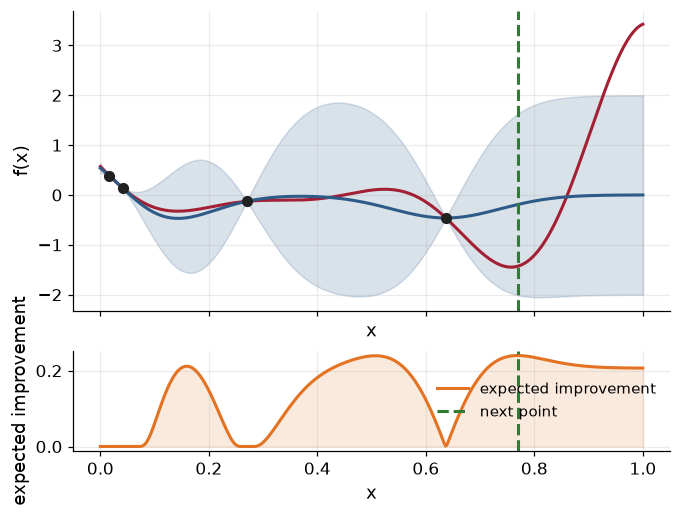

In [3]:
gp = GaussianProcess(lengthscale=0.1, noise_var=1e-4).fit(X_obs, y_obs)
mean, std = gp.posterior(xx[:, None])
ei = expected_improvement(mean, std, best=y_obs.min())
x_next = xx[np.argmax(ei)]

fig, (a0, a1) = plt.subplots(2, 1, figsize=(7, 5.2), sharex=True,
                             gridspec_kw=dict(height_ratios=[3, 1]))
plotting.plot_gp_1d(xx, mean, std, X_obs, y_obs, truth=f(xx), ax=a0)
a0.axvline(x_next, color=plotting.PICK, ls="--"); a0.legend().set_visible(False)
plotting.plot_acquisition(xx, ei, x_next, ax=a1, label="expected improvement")
plt.show()

For contrast, here is the lower confidence bound rule, which is given. It scores a point by its mean and rewards uncertainty (we are minimizing, so a promising point has a low mean and a large standard deviation). The knob $\beta$ is the explicit explore dial: larger $\beta$ means more exploration. In the lecture this was the dial that rescued the CARIBU tuning when it was stuck.

In [4]:
def lower_confidence_bound(mean, std, beta=2.0):
    # higher score is better; we reward a low mean and a large std
    return -(np.ravel(mean) - beta * np.ravel(std))

## The loop

Now assemble the four steps into one reusable function:

1. measure a few starting points,
2. fit the Gaussian process,
3. maximize the acquisition function to choose the next input,
4. measure there, add it to the data, and go back to step 2.

We work in the unit cube and map to the real bounds only when we call the objective, so one lengthscale works for any problem. We also scale the measured values to unit spread before fitting, so the same lengthscale and the same `xi` work whatever the scale of the objective. To maximize the acquisition we just score a large batch of random candidates and take the best, which is simple and good enough here. Fill in the part that chooses the next point.

In [ ]:
def bo_loop(objective, bounds, n_init=4, n_iter=20, lengthscale=0.12,
            noise_var=1e-4, xi=0.01, n_candidates=2000, seed=0):
    rng = np.random.default_rng(seed)
    bounds = np.atleast_2d(bounds).astype(float)   # shape (d, 2)
    d = len(bounds)

    def to_real(u):
        return bounds[:, 0] + u * (bounds[:, 1] - bounds[:, 0])

    U = rng.uniform(0, 1, size=(n_init, d))
    y = np.array([objective(to_real(u)) for u in U])

    for _ in range(n_iter):
        ym, ysd = y.mean(), y.std() + 1e-12
        gp = GaussianProcess(lengthscale=lengthscale, noise_var=noise_var).fit(U, (y - ym) / ysd)
        
        # TODO: choose the next point u_next in the unit cube.
        #   1. draw n_candidates random rows C in [0, 1]^d
        #   2. mean, std = gp.posterior(C)
        #   3. score = expected_improvement(mean, std, best=(y.min() - ym) / ysd, xi=xi)
        #   4. u_next = the candidate row with the highest score
        raise NotImplementedError

        U = np.vstack([U, u_next])
        y = np.append(y, objective(to_real(u_next)))

    return dict(U=U, X=np.array([to_real(u) for u in U]), y=y,
                best=np.minimum.accumulate(y))

Run it on the one-dimensional function and compare against random search with the same budget. A single run of random search can get lucky on a smooth one-dimensional problem, so we average twenty runs of each. Bayesian optimization reaches the minimum in fewer measurements.

In [6]:
def f_obj(x):
    return float(f(np.asarray(x).ravel()[0]))

bounds_1d = [(0.0, 1.0)]
n_runs, budget = 20, 18

bo_runs, rand_runs = [], []
for s in range(n_runs):
    bo_runs.append(bo_loop(f_obj, bounds_1d, n_init=3, n_iter=budget - 3,
                           lengthscale=0.1, seed=s)["best"])
    rg = np.random.default_rng(1000 + s)
    rand_runs.append(np.minimum.accumulate([f_obj(rg.uniform(0, 1)) for _ in range(budget)]))
bo_runs, rand_runs = np.array(bo_runs), np.array(rand_runs)

ev = np.arange(1, budget + 1)
for runs, label, color in [(bo_runs, "Bayesian optimization", plotting.MODEL),
                           (rand_runs, "random search", plotting.DATA)]:
    lo, hi = np.percentile(runs, [25, 75], axis=0)
    plt.plot(ev, runs.mean(0), marker="o", color=color, label=label)
    plt.fill_between(ev, lo, hi, color=color, alpha=0.15)
plt.axhline(float(f(forrester.argmin)), color=plotting.TRUTH, ls=":", label="true minimum")
plt.xlabel("number of measurements"); plt.ylabel("best value so far")
plt.legend(); plt.title("averaged over 20 runs: BO reaches the minimum sooner"); plt.show()
print("after 8 measurements, mean best value:",
      "  BO", round(bo_runs[:, 7].mean(), 3), "  random", round(rand_runs[:, 7].mean(), 3))

NotImplementedError: 

## Watch it learn

Here are the first several decisions. Each panel shows the posterior at that step and the point the acquisition picked. See how it explores the empty regions early, then settles near the minimum.

In [ ]:
Xs = rng.uniform(0, 1, size=3)
ys = f(Xs)

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True, sharey=True)
for ax in axes.ravel():
    gp = GaussianProcess(lengthscale=0.1, noise_var=1e-4).fit(Xs, ys)
    mean, std = gp.posterior(xx[:, None])
    ei = expected_improvement(mean, std, best=ys.min())
    x_next = xx[np.argmax(ei)]
    plotting.plot_gp_1d(xx, mean, std, Xs, ys, truth=f(xx), ax=ax)
    ax.axvline(x_next, color=plotting.PICK, ls="--")
    ax.legend().set_visible(False); ax.set_title(str(len(Xs)) + " measurements")
    Xs = np.append(Xs, x_next); ys = np.append(ys, f(x_next))
plt.tight_layout(); plt.show()

## A two-dimensional problem

The same loop works in higher dimensions without any change. Run it on the Branin function, which has three separate minima of equal depth. It should find one of them in a handful of measurements.

In [ ]:
def branin_obj(xy):
    return float(branin(np.asarray(xy).ravel()))

res2d = bo_loop(branin_obj, branin.bounds, n_init=6, n_iter=35, lengthscale=0.2, seed=0)
print("best Branin value found:", round(res2d["y"].min(), 3), " (the true minima sit at 0.398)")

ax = plotting.plot_convergence(res2d["best"], label="Bayesian optimization")
ax.axhline(0.397887, color=plotting.TRUTH, ls=":", label="true minimum")
ax.set_ylabel("best value so far"); ax.legend(); plt.show()

This is the core of the method. A cheap model decides where to spend the expensive measurement, and it reaches good points in far fewer of them than blind search.

It works well here because the problem is low dimensional and smooth. Our beamline is not: it has twelve correlated voltages, noisy counts, a mostly empty space, and two outputs in tension. Writing all of that from scratch is a real project. In the last part we hand the heavy lifting to a library and point it at the hard problem.